In [6]:
import os
import sys

if not hasattr(sys.modules[__name__], "cwd_changed"):
    os.chdir(os.path.dirname(os.path.dirname(os.path.abspath(__name__))))
    sys.modules[__name__].cwd_changed = True

from src.pipeline import *

In [7]:
os.getcwd()

'/courses/Thesis/Repository'

### Configs

### Configs

## Genetic Algorithm 

In [ ]:
from algorithms.benchmark import run_hc
from pipeline.dataclasses import Config
from pipeline.pipeline import Pipeline


configs = Config(
    folder='data/syntheticBinary/smallLowNoise',
    algorithm='hc',
    replications=1,
)
pipeline = Pipeline(run_hc, configs)
pipeline.get_true_dags()
pipeline.get_results()
pipeline.get_metrics()
# pipeline.get_metrics()
results = pipeline.get_result_data()
with open(f"results/{configs.algorithm}/{configs.folder.split('/')[-1]}_results.pkl", 'wb') as f:
    pickle.dump(results, f)

Loading data from folder: data/syntheticBinary/smallLowNoise
Running structure learning on datasets...


Processing CSV files: 100%|██████████| 10/10 [00:00<00:00, 13.01it/s]


Computing evaluation metrics...
Running experiment 1...
Experiment 1 Completed:


Running Experiment 2 on bnRep datasets:   0%|          | 0/3 [00:00<?, ?it/s]

Running experiment 2 for dataset: adversarialbehavior
Running experiment 2 for dataset: aerialvehicles
Running experiment 2 for dataset: agropastoral1


Running Experiment 2 on bnRep datasets: 100%|██████████| 3/3 [00:05<00:00,  1.76s/it]

Computing evaluation metrics...


In [ ]:

from utils.plotting import GraphVisualization
from pgmpy.estimators import BIC
idx = 2


metadata = dill.load(open(f"{pipeline.configs["folder"]}/{pipeline.metadata_by_id[idx]}", "rb"))
df = pd.read_csv(f"{pipeline.configs['folder']}/{pipeline.csv_by_id[idx]}")
graph_viz = GraphVisualization(pipeline.true_dags[idx], pipeline.learned_dags[idx],
                               metadata=metadata)
graph_viz.compare_dags_with_labels()


print(metadata)
print(pipeline.csv_by_id[idx])
print(pipeline.metadata_by_id[idx])

UnpicklingError: invalid load key, '7'.

In [ ]:
pipeline.true_dags

{0: <networkx.classes.digraph.DiGraph at 0x735dc8c0d100>,
 1: <networkx.classes.digraph.DiGraph at 0x735dc8c5f4d0>,
 2: <networkx.classes.digraph.DiGraph at 0x735dc8c5f110>,
 3: <networkx.classes.digraph.DiGraph at 0x735dc8c5f170>,
 4: <networkx.classes.digraph.DiGraph at 0x735dc8c5da00>,
 5: <networkx.classes.digraph.DiGraph at 0x735dc8c5f200>,
 6: <networkx.classes.digraph.DiGraph at 0x735dc8c5fec0>,
 7: <networkx.classes.digraph.DiGraph at 0x735dc8c5f140>,
 8: <networkx.classes.digraph.DiGraph at 0x735dc8c5fef0>,
 9: <networkx.classes.digraph.DiGraph at 0x735dc8c5fe60>}

In [ ]:
pipeline.learned_dags

{0: <networkx.classes.digraph.DiGraph at 0x735dc8e318b0>,
 1: <networkx.classes.digraph.DiGraph at 0x735dc8ca46e0>,
 2: <networkx.classes.digraph.DiGraph at 0x735dc8ca98e0>,
 3: <networkx.classes.digraph.DiGraph at 0x735dc8d161b0>,
 4: <networkx.classes.digraph.DiGraph at 0x735dc8cabe90>,
 5: <networkx.classes.digraph.DiGraph at 0x735dc8cc2360>,
 6: <networkx.classes.digraph.DiGraph at 0x735dc8dfb6e0>,
 7: <networkx.classes.digraph.DiGraph at 0x735dc8cabfb0>,
 8: <networkx.classes.digraph.DiGraph at 0x735dc8ca8320>,
 9: <networkx.classes.digraph.DiGraph at 0x735dc8caa540>}

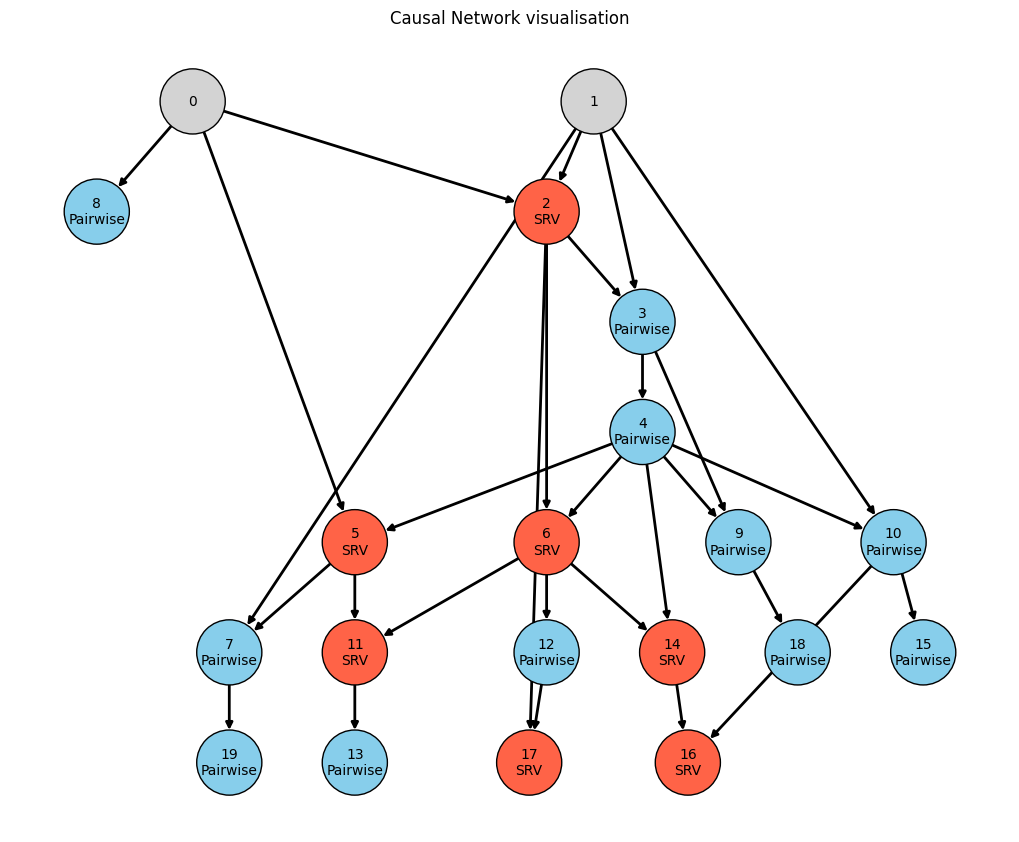

In [ ]:
graph_viz.visualize_network_labels()

In [ ]:
import logging
logging.getLogger('pgmpy').setLevel(logging.WARNING)


In [ ]:
pipeline.learned_dags

{0: <networkx.classes.digraph.DiGraph at 0x735dc8e318b0>,
 1: <networkx.classes.digraph.DiGraph at 0x735dc8ca46e0>,
 2: <networkx.classes.digraph.DiGraph at 0x735dc8ca98e0>,
 3: <networkx.classes.digraph.DiGraph at 0x735dc8d161b0>,
 4: <networkx.classes.digraph.DiGraph at 0x735dc8cabe90>,
 5: <networkx.classes.digraph.DiGraph at 0x735dc8cc2360>,
 6: <networkx.classes.digraph.DiGraph at 0x735dc8dfb6e0>,
 7: <networkx.classes.digraph.DiGraph at 0x735dc8cabfb0>,
 8: <networkx.classes.digraph.DiGraph at 0x735dc8ca8320>,
 9: <networkx.classes.digraph.DiGraph at 0x735dc8caa540>}

#### Two Roots

In [ ]:
from algorithms.benchmark import run_ea
from pipeline.pipeline import Pipeline


configs = {
        'folder': 'data/precomputed_cpds/two_roots',
        # "folder": 'data/BNs_Testing',
        'algorithm': 'genetic',
        'num_vars': 20,
        'num_samples': 10_000,
        'replications': 1
}

pipeline = Pipeline(configs, run_ea)
pipeline.get_true_dags()
pipeline.get_results()
pipeline.get_metrics()



Processing CSV files: 100%|██████████| 30/30 [00:14<00:00,  2.01it/s]


(-65753.31566703737, -67356.22709959433, -71832.62300941533, -67581.748459715, -61102.65700194342, -58255.75565627953, -61395.32918804135, -71900.10660851706, -65642.40264538868, -68190.5099179114, -69894.43882074411, -67936.13898599478, -67827.00117121758, -58807.61433816042, -49608.314415378554, -51718.460546072965, -56809.54049789275, -55996.59567013577, -70000.78653299839, -49835.28412560303, -59616.46001764103, -42945.82356413494, -60995.10879098342, -75444.59093209569, -72278.17033529807, -67334.98937666405, -70143.26881834192, -77655.90406622921, -76816.87544280809, -61251.535272776)
[-65753.31566703737, -67356.22709959433, -71832.62300941533, -67581.748459715, -61102.65700194342, -58255.75565627953, -61395.32918804135, -71900.10660851706, -65642.40264538868, -68190.5099179114, -69894.43882074411, -67936.13898599478, -67827.00117121758, -58807.61433816042, -49608.314415378554, -51718.460546072965, -56809.54049789275, -55996.59567013577, -70000.78653299839, -49835.28412560303, -5

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,14.000000,16.000000,17.000000,16.000000,20.000000,18.000000,16.000000,19.000000,14.000000,23.000000,...,14.000000,15.000000,17.000000,22.000000,22.000000,18.000000,13.000000,12.000000,20.000000,11.000000
False Positives,21.000000,23.000000,18.000000,20.000000,18.000000,22.000000,15.000000,26.000000,24.000000,13.000000,...,22.000000,18.000000,18.000000,11.000000,7.000000,23.000000,28.000000,21.000000,14.000000,23.000000
False Negatives,13.000000,13.000000,10.000000,11.000000,9.000000,11.000000,11.000000,10.000000,15.000000,6.000000,...,13.000000,11.000000,10.000000,7.000000,4.000000,10.000000,14.000000,14.000000,6.000000,14.000000
SHD,34.000000,36.000000,28.000000,31.000000,27.000000,33.000000,26.000000,36.000000,39.000000,19.000000,...,35.000000,29.000000,28.000000,18.000000,11.000000,33.000000,42.000000,35.000000,20.000000,37.000000
Precision,0.400000,0.410000,0.486000,0.444000,0.526000,0.450000,0.516000,0.422000,0.368000,0.639000,...,0.389000,0.455000,0.486000,0.667000,0.759000,0.439000,0.317000,0.364000,0.588000,0.324000
Recall,0.519000,0.552000,0.630000,0.593000,0.690000,0.621000,0.593000,0.655000,0.483000,0.793000,...,0.519000,0.577000,0.630000,0.759000,0.846000,0.643000,0.481000,0.462000,0.769000,0.440000
F1 Score,0.452000,0.471000,0.548000,0.508000,0.597000,0.522000,0.552000,0.514000,0.418000,0.708000,...,0.444000,0.508000,0.548000,0.710000,0.800000,0.522000,0.382000,0.407000,0.667000,0.373000
collider_precision,0.250000,0.250000,0.318182,0.142857,0.214286,0.225806,0.333333,0.128205,0.206897,0.217391,...,0.250000,0.190476,0.250000,0.388889,0.538462,0.181818,0.181818,0.277778,0.260870,0.142857
collider_recall,0.857143,1.000000,1.000000,0.571429,0.857143,1.000000,0.714286,0.714286,0.857143,0.714286,...,0.857143,0.571429,0.714286,1.000000,1.000000,0.857143,0.857143,0.714286,0.857143,0.428571
collider_f1,0.387097,0.400000,0.482759,0.228571,0.342857,0.368421,0.454545,0.217391,0.333333,0.333333,...,0.387097,0.285714,0.370370,0.560000,0.700000,0.300000,0.300000,0.400000,0.400000,0.214286


In [ ]:
pipeline.bic_scores[2]

-67827.00117121758

In [ ]:
pipeline.max_score[2]

-66809.86255259636

In [ ]:
# pipeline.learned_dags[2]

True Graph
[(0, 2), (0, 4), (0, 7), (0, 15), (1, 3), (1, 6), (1, 14), (1, 17), (4, 5), (4, 6), (4, 9), (4, 10), (4, 13), (4, 16), (5, 8), (5, 13), (6, 8), (6, 11), (7, 15), (10, 12), (11, 14), (12, 18), (12, 19), (13, 16), (13, 18), (16, 17), (18, 19)]
Learned Graph
[('0', '7'), ('0', '15'), ('0', '2'), ('7', '15'), ('1', '3'), ('1', '6'), ('1', '14'), ('1', '11'), ('6', '11'), ('6', '8'), ('14', '6'), ('14', '8'), ('14', '11'), ('4', '9'), ('4', '0'), ('4', '10'), ('4', '1'), ('4', '14'), ('4', '6'), ('10', '12'), ('5', '4'), ('5', '8'), ('12', '18'), ('12', '19'), ('19', '18'), ('13', '5'), ('13', '4'), ('13', '19'), ('13', '18'), ('16', '5'), ('16', '13'), ('16', '1'), ('16', '4'), ('17', '1'), ('17', '16')]

✅ Correct edges: [(0, 2), (0, 7), (0, 15), (1, 3), (1, 6), (1, 14), (4, 6), (4, 9), (4, 10), (5, 8), (6, 8), (6, 11), (7, 15), (10, 12), (12, 18), (12, 19), (13, 18)]
🔄 Wrong-direction edges: [(4, 0), (5, 4), (13, 4), (13, 5), (14, 11), (16, 4), (16, 13), (17, 1), (17, 16), (19

/courses/Thesis/Repository/src/graphviz.py:349: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


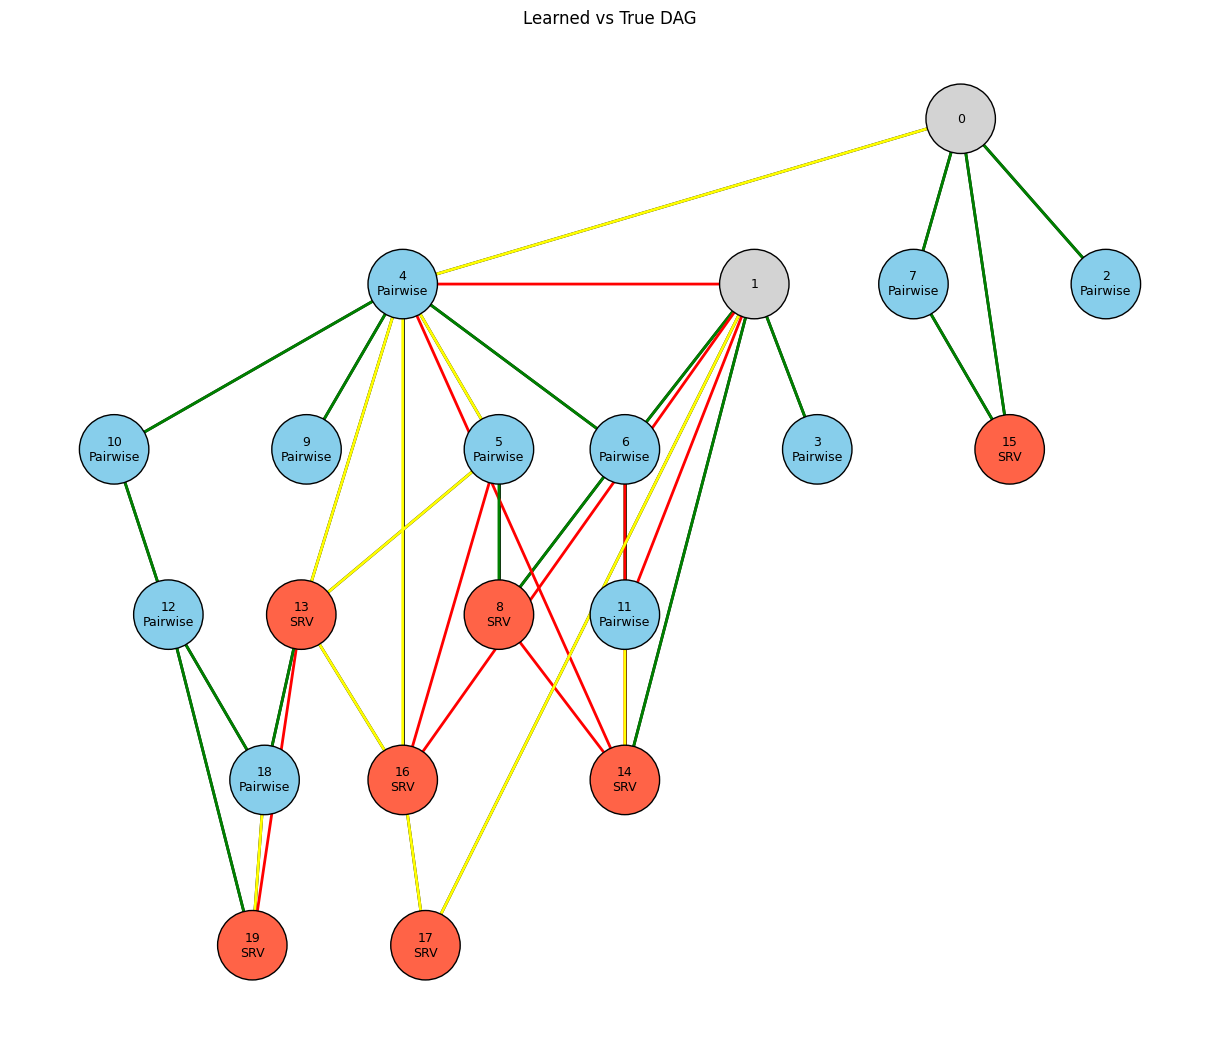

BIC score for the learned DAG: -67827.00117121758
           Combs      Type
0         [0, 2]  Pairwise
1         [1, 3]  Pairwise
2         [0, 4]  Pairwise
3         [4, 5]  Pairwise
4      [1, 4, 6]  Pairwise
5         [0, 7]  Pairwise
6      [5, 6, 8]       SRV
7         [4, 9]  Pairwise
8        [4, 10]  Pairwise
9        [6, 11]  Pairwise
10      [10, 12]  Pairwise
11    [4, 5, 13]       SRV
12   [1, 11, 14]       SRV
13    [0, 7, 15]       SRV
14   [4, 13, 16]       SRV
15   [1, 16, 17]       SRV
16  [12, 13, 18]  Pairwise
17  [12, 18, 19]       SRV
Data_Graph_2.csv
JOB_Initial_Test_Nodes_20_Graph_2_edges.dill


In [ ]:

from utils.plotting import GraphVisualization
from pgmpy.estimators import BIC

idx = 2

metadata = pipeline.metadata[idx]
df = pipeline.df_by_id[idx]


graph_viz = GraphVisualization(pipeline.true_dags[idx], pipeline.learned_dags[idx],
                               metadata=metadata)
graph_viz.compare_dags_with_labels()

scorer = BIC(df)
# mapping = {n: str(n) for n in pipeline.true_dags[idx].nodes()}  # convert all int nodes to str
# G = nx.relabel_nodes(pipeline.true_dags[idx], mapping)
# print("BIC score for the true DAG:", scorer.score(G))
# scorer.score(G)


print("BIC score for the learned DAG:", scorer.score(pipeline.learned_dags[idx]))
print(metadata)
print(pipeline.csv_by_id[idx])
print(pipeline.metadata_by_id[idx])

#### Three Roots

In [ ]:
from algorithms.benchmark import run_ea
from pipeline.pipeline import Pipeline


configs = {
        'folder': 'data/precomputed_cpds/three_roots',
        'algorithm': 'genetic',
        'num_vars': 20,
        'num_samples': 10_000,
        'replications': 1
}

pipeline_threeroots = Pipeline(configs, run_ea)
pipeline_threeroots.get_true_dags()
pipeline_threeroots.get_results()
pipeline_threeroots.get_metrics()

Processing CSV files: 100%|██████████| 30/30 [00:14<00:00,  2.12it/s]


(-71824.88568352428, -54565.02350390214, -65750.57358469834, -67031.89116286462, -60785.46335664023, -62914.653549984534, -68525.30161406317, -51632.36736836383, -50167.34085777891, -72023.08291393371, -52063.95919370848, -64879.76974394738, -61597.5678986182, -63348.373592065494, -51613.28807632486, -65571.65921084094, -60699.252012601595, -52625.54754898385, -73357.08130105227, -69277.61659069265, -80348.48170110727, -81869.45236693091, -63672.60402218257, -71139.19061042769, -63770.21483772335, -66762.75704701182, -60856.85753473452, -68508.19956501278, -73486.42962553434, -55275.39566992306)
[-71824.88568352428, -54565.02350390214, -65750.57358469834, -67031.89116286462, -60785.46335664023, -62914.653549984534, -68525.30161406317, -51632.36736836383, -50167.34085777891, -72023.08291393371, -52063.95919370848, -64879.76974394738, -61597.5678986182, -63348.373592065494, -51613.28807632486, -65571.65921084094, -60699.252012601595, -52625.54754898385, -73357.08130105227, -69277.6165906

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,20.000000,20.000000,17.000000,15.000000,15.000000,17.000000,20.000000,14.000000,20.000000,18.000000,...,1.000000,15.000000,18.000000,17.000000,21.000000,17.000000,20.000000,15.000000,16.000000,18.000000
False Positives,14.000000,8.000000,14.000000,18.000000,20.000000,18.000000,9.000000,16.000000,11.000000,18.000000,...,32.000000,12.000000,14.000000,16.000000,8.000000,12.000000,11.000000,19.000000,21.000000,21.000000
False Negatives,8.000000,5.000000,10.000000,11.000000,12.000000,10.000000,8.000000,11.000000,6.000000,9.000000,...,29.000000,10.000000,9.000000,9.000000,5.000000,7.000000,8.000000,10.000000,12.000000,12.000000
SHD,22.000000,13.000000,24.000000,29.000000,32.000000,28.000000,17.000000,27.000000,17.000000,27.000000,...,61.000000,22.000000,23.000000,25.000000,13.000000,19.000000,19.000000,29.000000,33.000000,33.000000
Precision,0.588000,0.714000,0.548000,0.455000,0.429000,0.486000,0.690000,0.467000,0.645000,0.500000,...,0.030000,0.556000,0.562000,0.515000,0.724000,0.586000,0.645000,0.441000,0.432000,0.462000
Recall,0.714000,0.800000,0.630000,0.577000,0.556000,0.630000,0.714000,0.560000,0.769000,0.667000,...,0.033000,0.600000,0.667000,0.654000,0.808000,0.708000,0.714000,0.600000,0.571000,0.600000
F1 Score,0.645000,0.755000,0.586000,0.508000,0.484000,0.548000,0.702000,0.509000,0.702000,0.571000,...,0.032000,0.577000,0.610000,0.576000,0.764000,0.642000,0.678000,0.508000,0.492000,0.522000
collider_precision,0.375000,0.461538,0.352941,0.210526,0.285714,0.260870,0.538462,0.285714,0.375000,0.291667,...,0.000000,0.625000,0.466667,0.260870,0.428571,0.235294,0.500000,0.333333,0.304348,0.200000
collider_recall,0.857143,0.857143,0.857143,0.571429,0.857143,0.857143,1.000000,0.571429,0.857143,1.000000,...,0.000000,0.714286,1.000000,0.857143,0.857143,0.571429,1.000000,1.000000,1.000000,0.857143
collider_f1,0.521739,0.600000,0.500000,0.307692,0.428571,0.400000,0.700000,0.380952,0.521739,0.451613,...,0.000000,0.666667,0.636364,0.400000,0.571429,0.333333,0.666667,0.500000,0.466667,0.324324


### Testing order of graphs


In [ ]:
from utils.plotting import GraphVisualization

In [ ]:
with open(f"{configs['folder']}/{pipeline.metadata_by_id[0]}", "rb") as f:
    meta_df = dill.load(f)
g = GraphVisualization(graph=pipeline.true_dags[0], metadata=meta_df, results=pipeline.learned_dags[0])

In [ ]:
meta_df

,Combs,Type
0,"[0, 2, 3]",SRV
1,"[2, 3, 4]",SRV
2,"[3, 5]",Pairwise
3,"[3, 6]",Pairwise
4,"[6, 7]",Pairwise
5,"[0, 6, 8]",Pairwise
6,"[2, 9]",Pairwise
7,"[1, 4, 10]",SRV
8,"[7, 9, 11]",SRV
9,"[3, 5, 12]",SRV


## True triplets

In [ ]:
pipeline.triplets_found(0)

AttributeError: 'Pipeline' object has no attribute 'triplets_found'

In [ ]:
pipeline.learned_dags[0]

True Graph
[(0, 2), (0, 3), (0, 6), (0, 12), (0, 14), (0, 18), (2, 4), (2, 5), (2, 9), (1, 2), (1, 11), (3, 4), (3, 5), (3, 9), (3, 13), (4, 14), (5, 16), (6, 7), (7, 8), (7, 10), (7, 11), (10, 12), (12, 13), (12, 16), (14, 15), (14, 17), (16, 17), (17, 18), (17, 19)]
Learned Graph
[('0', '3'), ('0', '2'), ('0', '14'), ('0', '12'), ('0', '18'), ('3', '14'), ('3', '5'), ('3', '13'), ('3', '9'), ('3', '4'), ('2', '4'), ('2', '14'), ('2', '5'), ('2', '9'), ('14', '15'), ('14', '17'), ('12', '13'), ('12', '16'), ('1', '11'), ('1', '2'), ('5', '16'), ('9', '4'), ('16', '17'), ('6', '0'), ('7', '6'), ('7', '10'), ('7', '11'), ('10', '12'), ('8', '7'), ('17', '19'), ('17', '18')]

✅ Correct edges: [(0, 2), (0, 3), (0, 12), (0, 14), (0, 18), (1, 2), (1, 11), (2, 4), (2, 5), (2, 9), (3, 4), (3, 5), (3, 9), (3, 13), (5, 16), (7, 10), (7, 11), (10, 12), (12, 13), (12, 16), (14, 15), (14, 17), (16, 17), (17, 18), (17, 19)]
🔄 Wrong-direction edges: [(6, 0), (7, 6), (8, 7)]
⚠️ Extra edges: [(2, 14),

/courses/Thesis/Repository/src/graphviz.py:349: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


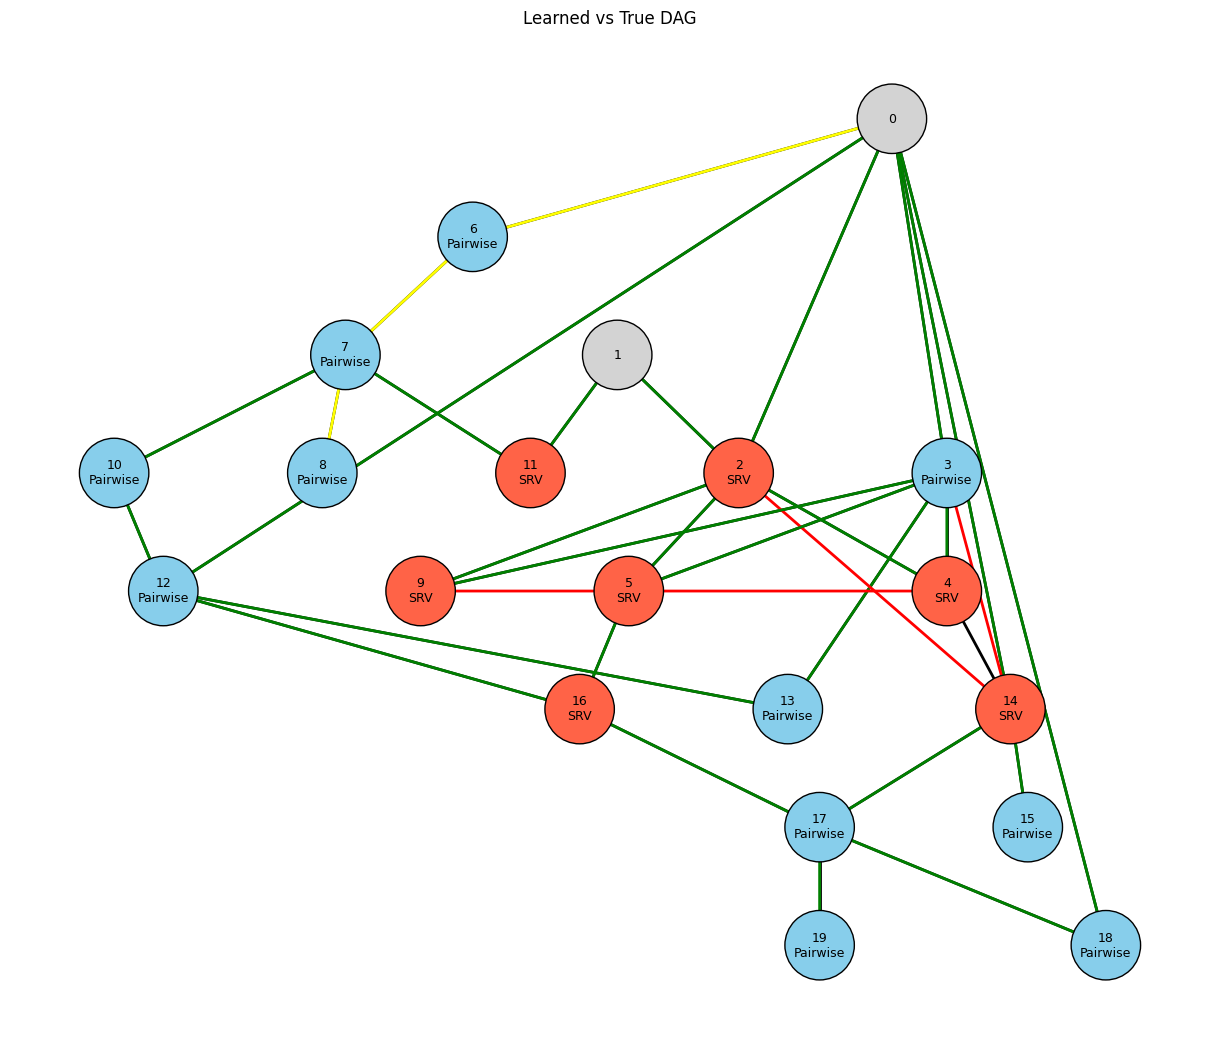

In [ ]:
g.compare_dags_with_labels()

## Hillclimber

In [ ]:
from algorithms.benchmark import run_hc
from pipeline.pipeline import Pipeline

configs = {
        # 'folder': 'data/precomputed_cpds/two_roots',
        "folder": 'data/BNs_Testing',
        'algorithm': 'genetic',
        'num_vars': 20,
        'num_samples': 10_000,
        'replications': 1
    }
pipeline = Pipeline(configs, run_hc)
pipeline.get_true_dags()

# pipeline.get_metrics()

In [ ]:
pipeline.get_results()

Processing CSV files:   0%|          | 0/3 [00:00<?, ?it/s]INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19'

{0: <networkx.classes.digraph.DiGraph at 0x77c2c97f3440>,
 1: <networkx.classes.digraph.DiGraph at 0x77c191123d10>,
 2: <networkx.classes.digraph.DiGraph at 0x77c1945602f0>}

In [ ]:
pipeline.get_metrics()

True triplets for 0: 0      [0, 2, 5]
3      [1, 7, 8]
4      [4, 7, 9]
10    [3, 4, 15]
11    [0, 8, 16]
12    [1, 8, 17]
Name: Combs, dtype: object
Learned triplets for 0: [('0', '16', '8'), ('0', '2', '5'), ('0', '14', '9'), ('1', '8', '7'), ('1', '8', '17'), ('7', '8', '17'), ('1', '17', '7'), ('3', '15', '4'), ('7', '4', '9'), ('9', '19', '16')]
✅ Correctly learned triplets:
[3, 4, 15]
[0, 2, 5]
[4, 7, 9]
[1, 7, 8]
[1, 8, 17]
[0, 8, 16]

❌ Missing triplets (true but not learned):

⚠️ Extra triplets (learned but not true):
[7, 8, 17]
[9, 16, 19]
[1, 7, 17]
[0, 9, 14]
True triplets for 1: 2       [0, 4, 7]
6     [3, 10, 11]
7      [2, 9, 12]
11    [1, 10, 16]
12    [3, 14, 17]
13    [1, 11, 18]
Name: Combs, dtype: object
Learned triplets for 1: [('0', '4', '7'), ('11', '1', '18'), ('1', '16', '10'), ('4', '3', '10'), ('4', '3', '11'), ('10', '3', '11'), ('3', '17', '14'), ('4', '11', '10'), ('5', '7', '14'), ('7', '19', '8'), ('9', '2', '12')]
✅ Correctly learned triplets:
[3, 14, 1

,0,1,2
True Positives,14.000000,14.000000,13.000000
False Positives,11.000000,15.000000,17.000000
False Negatives,9.000000,9.000000,11.000000
SHD,20.000000,24.000000,28.000000
Precision,0.560000,0.483000,0.433000
Recall,0.609000,0.609000,0.542000
F1 Score,0.583000,0.538000,0.481000
BIC,-68335.203545,-78173.603449,-81562.852655
triplets_found,6.000000,6.000000,6.000000


## Experiment 1

In [ ]:
from algorithms.ea import GeneticBNSearch

In [ ]:
df = pd.read_csv(f"{configs['folder']}/{pipeline.csv_by_id[5]}")

KeyError: 5

In [ ]:
df.columns = df.columns.astype(int)

In [ ]:
df.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19'],
      dtype='object')

In [ ]:
from pgmpy.estimators import BIC

score = BIC(df)
# score.score(pipeline.true_dags[5])
# pipeline.true_dags[1].nodes()


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}


KeyError: 0

In [ ]:
mapping = {i: str(i) for i in range(20)}
nx.relabel_nodes(pipeline.true_dags[1], mapping)
ea = GeneticBNSearch(data=df, score_fn="bic")
df.columns = df.columns.astype(str)
ea._score(graph=pipeline.true_dags[1])  # Use the true DAG for




INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}


KeyError: 0

In [ ]:
pipeline.true_dags[0]

In [ ]:
with open(f"{configs['folder']}/{pipeline.metadata_by_id[0]}", "rb") as f:
    meta_df = dill.load(f)

In [ ]:
pipeline.true_dags[1]

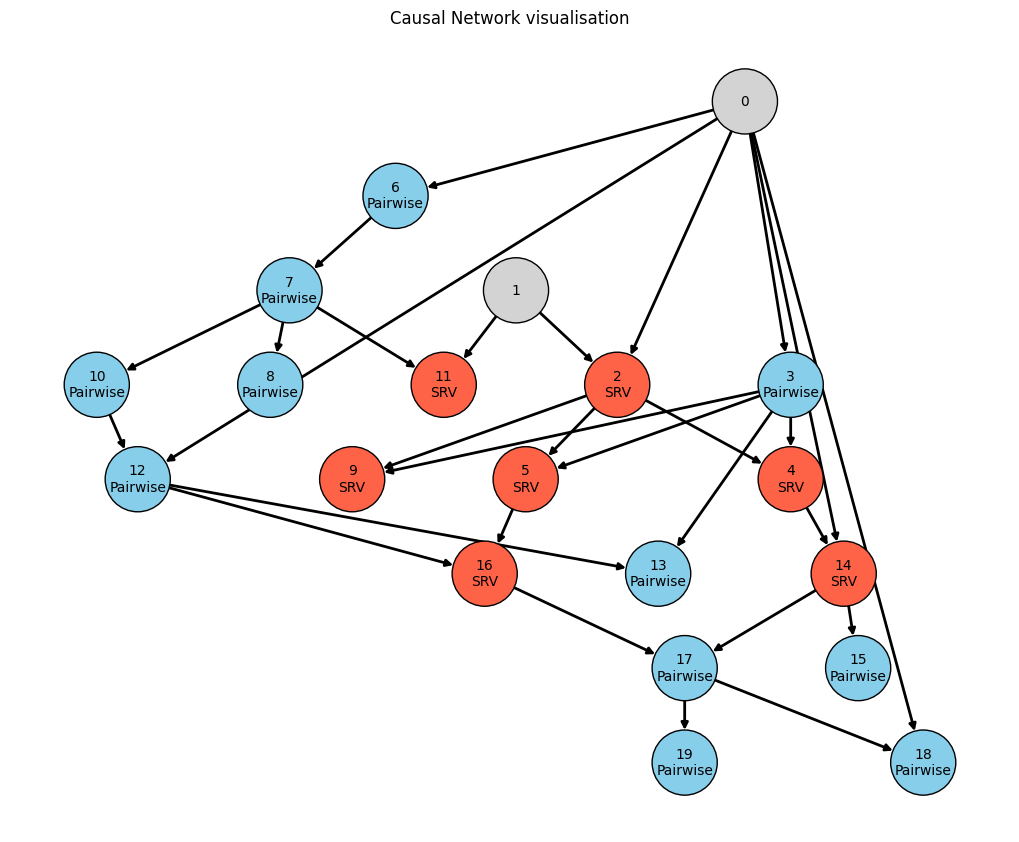

In [ ]:
viz = GraphVisualization(graph=pipeline.true_dags[0], metadata=meta_df)
viz.visualize_network_labels()

In [ ]:
pipeline.get_metrics()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,23.000,18.000,20.000,12.000,13.000,19.000,15.000,18.000,15.000,21.000,...,24.000,21.000,23.000,22.000,15.000,18.000,14.000,18.000,18.000,14.000
False Positives,11.000,19.000,21.000,24.000,25.000,20.000,18.000,10.000,15.000,6.000,...,13.000,16.000,8.000,19.000,16.000,18.000,19.000,24.000,18.000,16.000
False Negatives,6.000,10.000,9.000,17.000,13.000,10.000,12.000,9.000,11.000,6.000,...,5.000,6.000,4.000,8.000,13.000,11.000,14.000,10.000,10.000,13.000
SHD,17.000,29.000,30.000,41.000,38.000,30.000,30.000,19.000,26.000,12.000,...,18.000,22.000,12.000,27.000,29.000,29.000,33.000,34.000,28.000,29.000
Precision,0.676,0.486,0.488,0.333,0.342,0.487,0.455,0.643,0.500,0.778,...,0.649,0.568,0.742,0.537,0.484,0.500,0.424,0.429,0.500,0.467
Recall,0.793,0.643,0.690,0.414,0.500,0.655,0.556,0.667,0.577,0.778,...,0.828,0.778,0.852,0.733,0.536,0.621,0.500,0.643,0.643,0.519
F1 Score,0.730,0.554,0.571,0.369,0.406,0.559,0.500,0.655,0.536,0.778,...,0.727,0.656,0.793,0.620,0.508,0.554,0.459,0.514,0.563,0.491


In [ ]:
pipeline.eval_metrics

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,23.000,18.000,20.000,12.000,13.000,19.000,15.000,18.000,15.000,21.000,...,24.000,21.000,23.000,22.000,15.000,18.000,14.000,18.000,18.000,14.000
False Positives,11.000,19.000,21.000,24.000,25.000,20.000,18.000,10.000,15.000,6.000,...,13.000,16.000,8.000,19.000,16.000,18.000,19.000,24.000,18.000,16.000
False Negatives,6.000,10.000,9.000,17.000,13.000,10.000,12.000,9.000,11.000,6.000,...,5.000,6.000,4.000,8.000,13.000,11.000,14.000,10.000,10.000,13.000
SHD,17.000,29.000,30.000,41.000,38.000,30.000,30.000,19.000,26.000,12.000,...,18.000,22.000,12.000,27.000,29.000,29.000,33.000,34.000,28.000,29.000
Precision,0.676,0.486,0.488,0.333,0.342,0.487,0.455,0.643,0.500,0.778,...,0.649,0.568,0.742,0.537,0.484,0.500,0.424,0.429,0.500,0.467
Recall,0.793,0.643,0.690,0.414,0.500,0.655,0.556,0.667,0.577,0.778,...,0.828,0.778,0.852,0.733,0.536,0.621,0.500,0.643,0.643,0.519
F1 Score,0.730,0.554,0.571,0.369,0.406,0.559,0.500,0.655,0.536,0.778,...,0.727,0.656,0.793,0.620,0.508,0.554,0.459,0.514,0.563,0.491


In [ ]:
pipeline.bic_scores

{0: -65500.13069885992,
 1: -66832.97589282806,
 10: -70303.78706823084,
 11: -60995.10879098343,
 12: -75444.59093209569,
 13: -71850.0822179362,
 14: -67358.74620494073,
 15: -70178.5730755362,
 16: -76978.00308911092,
 17: -78763.89340446533,
 18: -71162.75290356476,
 19: -65155.344919713534,
 2: -61624.987319870044,
 20: -58867.84477501723,
 21: -61398.60735571852,
 22: -72230.9944441518,
 23: -67958.64602953602,
 24: -69671.83437568836,
 25: -70493.27661087352,
 27: -67936.13898599478,
 28: -58972.26900901214,
 29: -49483.853810316235,
 3: -51718.460546072965,
 4: -56768.21674582784,
 5: -56343.215694725484,
 6: -67975.85732681635,
 7: -61204.27895478249,
 8: -49835.28412560303,
 9: -58935.71594179982,
 26: -42945.82356413494}

True Graph
[(0, 2), (0, 4), (0, 7), (0, 15), (1, 3), (1, 6), (1, 14), (1, 17), (4, 5), (4, 6), (4, 9), (4, 10), (4, 13), (4, 16), (5, 8), (5, 13), (6, 8), (6, 11), (7, 15), (10, 12), (11, 14), (12, 18), (12, 19), (13, 16), (13, 18), (16, 17), (18, 19)]
Learned Graph
[('0', '7'), ('0', '15'), ('0', '2'), ('7', '15'), ('1', '6'), ('1', '14'), ('1', '8'), ('1', '17'), ('1', '11'), ('6', '11'), ('6', '9'), ('6', '8'), ('6', '17'), ('14', '6'), ('14', '11'), ('8', '9'), ('17', '8'), ('3', '1'), ('4', '5'), ('4', '0'), ('4', '10'), ('4', '16'), ('5', '16'), ('10', '12'), ('9', '4'), ('12', '18'), ('12', '19'), ('19', '18'), ('13', '16'), ('13', '5'), ('13', '9'), ('13', '19'), ('13', '8'), ('13', '17'), ('13', '14'), ('13', '18')]

✅ Correct edges: [(0, 2), (0, 7), (0, 15), (1, 6), (1, 14), (1, 17), (4, 5), (4, 10), (4, 16), (6, 8), (6, 11), (7, 15), (10, 12), (12, 18), (12, 19), (13, 16), (13, 18)]
🔄 Wrong-direction edges: [(3, 1), (4, 0), (9, 4), (13, 5), (14, 11), (19, 18)]
⚠️ Extra edges

/courses/Thesis/Repository/src/graphviz.py:349: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


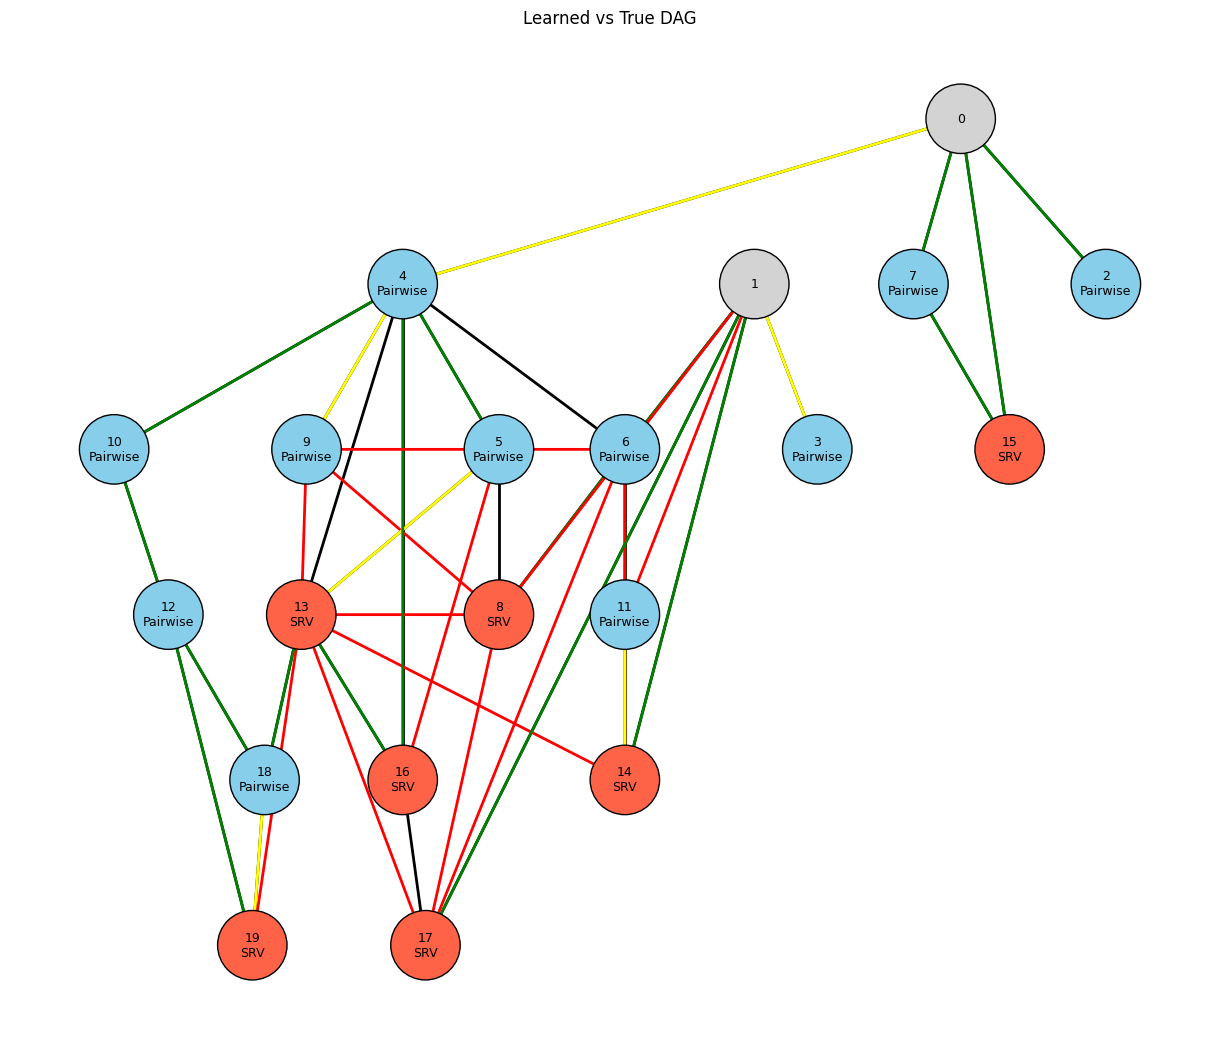

BIC score for the true DAG: -66809.86255259636
BIC score for the learned DAG: -70406.03925759353
           Combs      Type
0         [0, 2]  Pairwise
1         [1, 3]  Pairwise
2         [0, 4]  Pairwise
3         [4, 5]  Pairwise
4      [1, 4, 6]  Pairwise
5         [0, 7]  Pairwise
6      [5, 6, 8]       SRV
7         [4, 9]  Pairwise
8        [4, 10]  Pairwise
9        [6, 11]  Pairwise
10      [10, 12]  Pairwise
11    [4, 5, 13]       SRV
12   [1, 11, 14]       SRV
13    [0, 7, 15]       SRV
14   [4, 13, 16]       SRV
15   [1, 16, 17]       SRV
16  [12, 13, 18]  Pairwise
17  [12, 18, 19]       SRV
Data_Graph_2.csv
JOB_Initial_Test_Nodes_20_Graph_2_edges.dill


In [ ]:

from utils.plotting import GraphVisualization
from pgmpy.estimators import BIC
idx = 2


metadata = dill.load(open(f"{pipeline.configs["folder"]}/{pipeline.metadata_by_id[idx]}", "rb"))
df = pd.read_csv(f"{pipeline.configs['folder']}/{pipeline.csv_by_id[idx]}")
graph_viz = GraphVisualization(pipeline.true_dags[idx], pipeline.learned_dags[idx],
                               metadata=metadata)
graph_viz.compare_dags_with_labels()

scorer = BIC(df)
mapping = {n: str(n) for n in pipeline.true_dags[2].nodes()}  # convert all int nodes to str
G = nx.relabel_nodes(pipeline.true_dags[idx], mapping)
print("BIC score for the true DAG:", scorer.score(G))
scorer.score(G)

# for idx in range(len(pipeline_tworoots.learned_dags)):
print("BIC score for the learned DAG:", scorer.score(pipeline.learned_dags[idx]))
print(metadata)
print(pipeline.csv_by_id[idx])
print(pipeline.metadata_by_id[idx])

#### Three Roots

In [ ]:
from algorithms.benchmark import run_ea
from pipeline.pipeline import Pipeline


configs = {
        'folder': 'data/precomputed_cpds/three_roots',
        'algorithm': 'genetic',
        'num_vars': 20,
        'num_samples': 10_000,
        'replications': 1
}

pipeline_threeroots = Pipeline(configs, run_ea)
pipeline_threeroots.get_true_dags()
pipeline_threeroots.get_results()
pipeline_threeroots.get_metrics()

Processing CSV files: 100%|██████████| 30/30 [00:13<00:00,  2.21it/s]


(-71841.22702975663, -54565.02350390214, -66270.55276722852, -67031.89116286462, -60863.98912434249, -66893.66473305385, -68534.07413093775, -50867.22518252835, -50135.84640998085, -72176.07948829277, -52302.32720607312, -64879.76974394738, -61062.207621275185, -63511.32801213775, -51613.28807632486, -65284.25067979451, -60375.50559234087, -52625.54754898385, -73378.28891314856, -69100.06960459461, -80348.48170110727, -83684.28275324119, -63672.60402218257, -71209.23541876364, -64247.976756187796, -66762.75704701182, -60803.478382916684, -68508.19956501278, -73539.72186716463, -56418.80619449553)
[-71841.22702975663, -54565.02350390214, -66270.55276722852, -67031.89116286462, -60863.98912434249, -66893.66473305385, -68534.07413093775, -50867.22518252835, -50135.84640998085, -72176.07948829277, -52302.32720607312, -64879.76974394738, -61062.207621275185, -63511.32801213775, -51613.28807632486, -65284.25067979451, -60375.50559234087, -52625.54754898385, -73378.28891314856, -69100.0696045

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,20.000000,20.000000,19.000000,15.000000,14.000000,18.000000,21.000000,15.000000,20.000000,16.000000,...,2.000000,16.000000,17.000000,18.000000,12.000000,17.000000,17.000000,20.000000,16.000000,14.000000
False Positives,14.000000,8.000000,10.000000,18.000000,21.000000,15.000000,8.000000,14.000000,11.000000,21.000000,...,29.000000,11.000000,13.000000,17.000000,18.000000,12.000000,14.000000,10.000000,21.000000,28.000000
False Negatives,8.000000,5.000000,8.000000,11.000000,13.000000,9.000000,7.000000,10.000000,6.000000,11.000000,...,28.000000,9.000000,10.000000,8.000000,14.000000,7.000000,11.000000,5.000000,12.000000,16.000000
SHD,22.000000,13.000000,18.000000,29.000000,34.000000,24.000000,15.000000,24.000000,17.000000,32.000000,...,57.000000,20.000000,23.000000,25.000000,32.000000,19.000000,25.000000,15.000000,33.000000,44.000000
Precision,0.588000,0.714000,0.655000,0.455000,0.400000,0.545000,0.724000,0.517000,0.645000,0.432000,...,0.065000,0.593000,0.567000,0.514000,0.400000,0.586000,0.548000,0.667000,0.432000,0.333000
Recall,0.714000,0.800000,0.704000,0.577000,0.519000,0.667000,0.750000,0.600000,0.769000,0.593000,...,0.067000,0.640000,0.630000,0.692000,0.462000,0.708000,0.607000,0.800000,0.571000,0.467000
F1 Score,0.645000,0.755000,0.679000,0.508000,0.452000,0.600000,0.737000,0.556000,0.702000,0.500000,...,0.066000,0.615000,0.596000,0.590000,0.429000,0.642000,0.576000,0.727000,0.492000,0.389000
collider_precision,0.411765,0.461538,0.461538,0.210526,0.285714,0.250000,0.538462,0.307692,0.375000,0.280000,...,0.000000,0.625000,0.636364,0.230769,0.583333,0.235294,0.500000,0.388889,0.304348,0.166667
collider_recall,1.000000,0.857143,0.857143,0.571429,0.857143,0.714286,1.000000,0.571429,0.857143,1.000000,...,0.000000,0.714286,1.000000,0.857143,1.000000,0.571429,1.000000,1.000000,1.000000,0.857143
collider_f1,0.583333,0.600000,0.600000,0.307692,0.428571,0.370370,0.700000,0.400000,0.521739,0.437500,...,0.000000,0.666667,0.777778,0.363636,0.736842,0.333333,0.666667,0.560000,0.466667,0.279070


#### Two roots test

In [ ]:
from algorithms.benchmark import run_ea
from pipeline.pipeline import Pipeline


configs = {
        'folder': 'data/two_roots_test',
        'algorithm': 'genetic',
        'num_vars': 20,
        'num_samples': 10_000,
        'replications': 1
}

pipeline_tworootstest = Pipeline(configs, run_ea)
pipeline_tworootstest.get_true_dags()
pipeline_tworootstest.get_results()
pipeline_tworootstest.get_metrics()

Processing CSV files: 100%|██████████| 30/30 [00:16<00:00,  1.83it/s]


,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,16.000000,14.000000,15.000000,13.000000,20.000000,16.000000,16.000000,15.000000,14.000000,17.000000,...,15.000000,14.000000,15.000000,21.000000,19.000000,20.000000,19.000000,18.000000,21.000000,18.000000
False Positives,25.000000,25.000000,22.000000,23.000000,12.000000,16.000000,17.000000,25.000000,24.000000,15.000000,...,29.000000,26.000000,34.000000,15.000000,19.000000,21.000000,19.000000,13.000000,12.000000,11.000000
False Negatives,13.000000,14.000000,16.000000,15.000000,7.000000,12.000000,11.000000,12.000000,15.000000,11.000000,...,13.000000,13.000000,15.000000,8.000000,9.000000,10.000000,11.000000,9.000000,8.000000,9.000000
SHD,38.000000,39.000000,38.000000,38.000000,19.000000,28.000000,28.000000,37.000000,39.000000,26.000000,...,42.000000,39.000000,49.000000,23.000000,28.000000,31.000000,30.000000,22.000000,20.000000,20.000000
Precision,0.390000,0.359000,0.405000,0.361000,0.625000,0.500000,0.485000,0.375000,0.368000,0.531000,...,0.341000,0.350000,0.306000,0.583000,0.500000,0.488000,0.500000,0.581000,0.636000,0.621000
Recall,0.552000,0.500000,0.484000,0.464000,0.741000,0.571000,0.593000,0.556000,0.483000,0.607000,...,0.536000,0.519000,0.500000,0.724000,0.679000,0.667000,0.633000,0.667000,0.724000,0.667000
F1 Score,0.457000,0.418000,0.441000,0.406000,0.678000,0.533000,0.533000,0.448000,0.418000,0.567000,...,0.417000,0.418000,0.380000,0.646000,0.576000,0.563000,0.559000,0.621000,0.677000,0.643000
collider_precision,0.225806,0.222222,0.095238,0.047619,0.062500,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.047619,0.000000,0.020833,0.041667,0.000000,0.000000,0.080000,0.000000,0.000000,0.000000
collider_recall,1.000000,0.857143,0.285714,0.142857,0.142857,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.285714,0.000000,0.142857,0.142857,0.000000,0.000000,0.285714,0.000000,0.000000,0.000000
collider_f1,0.368421,0.352941,0.142857,0.071429,0.086957,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.081633,0.000000,0.036364,0.064516,0.000000,0.000000,0.125000,0.000000,0.000000,0.000000


### Testing order of graphs


In [ ]:
from utils.plotting import GraphVisualization

In [ ]:
with open(f"{configs['folder']}/{pipeline.metadata_by_id[0]}", "rb") as f:
    meta_df = dill.load(f)
g = GraphVisualization(graph=pipeline.true_dags[0], metadata=meta_df, results=pipeline.learned_dags[0])

In [ ]:
meta_df

,Combs,Type
0,"[0, 1, 2]",SRV
1,"[1, 2, 3]",Pairwise
2,"[3, 4]",Pairwise
3,"[2, 5]",Pairwise
4,"[0, 1, 6]",Pairwise
5,"[0, 5, 7]",Pairwise
6,"[0, 2, 8]",SRV
7,"[1, 4, 9]",Pairwise
8,"[4, 10]",Pairwise
9,"[5, 6, 11]",SRV


## True triplets

In [ ]:
pipeline.triplets_found(0)

AttributeError: 'Pipeline' object has no attribute 'triplets_found'

In [ ]:
pipeline.learned_dags[0]

True Graph
[(0, 2), (0, 3), (0, 6), (0, 12), (0, 14), (0, 18), (2, 4), (2, 5), (2, 9), (1, 2), (1, 11), (3, 4), (3, 5), (3, 9), (3, 13), (4, 14), (5, 16), (6, 7), (7, 8), (7, 10), (7, 11), (10, 12), (12, 13), (12, 16), (14, 15), (14, 17), (16, 17), (17, 18), (17, 19)]
Learned Graph
[('0', '3'), ('0', '2'), ('0', '14'), ('0', '12'), ('0', '18'), ('3', '14'), ('3', '5'), ('3', '13'), ('3', '9'), ('3', '4'), ('2', '4'), ('2', '14'), ('2', '5'), ('2', '9'), ('14', '15'), ('14', '17'), ('12', '13'), ('12', '16'), ('1', '11'), ('1', '2'), ('5', '16'), ('9', '4'), ('16', '17'), ('6', '0'), ('7', '6'), ('7', '10'), ('7', '11'), ('10', '12'), ('8', '7'), ('17', '19'), ('17', '18')]

✅ Correct edges: [(0, 2), (0, 3), (0, 12), (0, 14), (0, 18), (1, 2), (1, 11), (2, 4), (2, 5), (2, 9), (3, 4), (3, 5), (3, 9), (3, 13), (5, 16), (7, 10), (7, 11), (10, 12), (12, 13), (12, 16), (14, 15), (14, 17), (16, 17), (17, 18), (17, 19)]
🔄 Wrong-direction edges: [(6, 0), (7, 6), (8, 7)]
⚠️ Extra edges: [(2, 14),

/courses/Thesis/Repository/src/graphviz.py:349: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


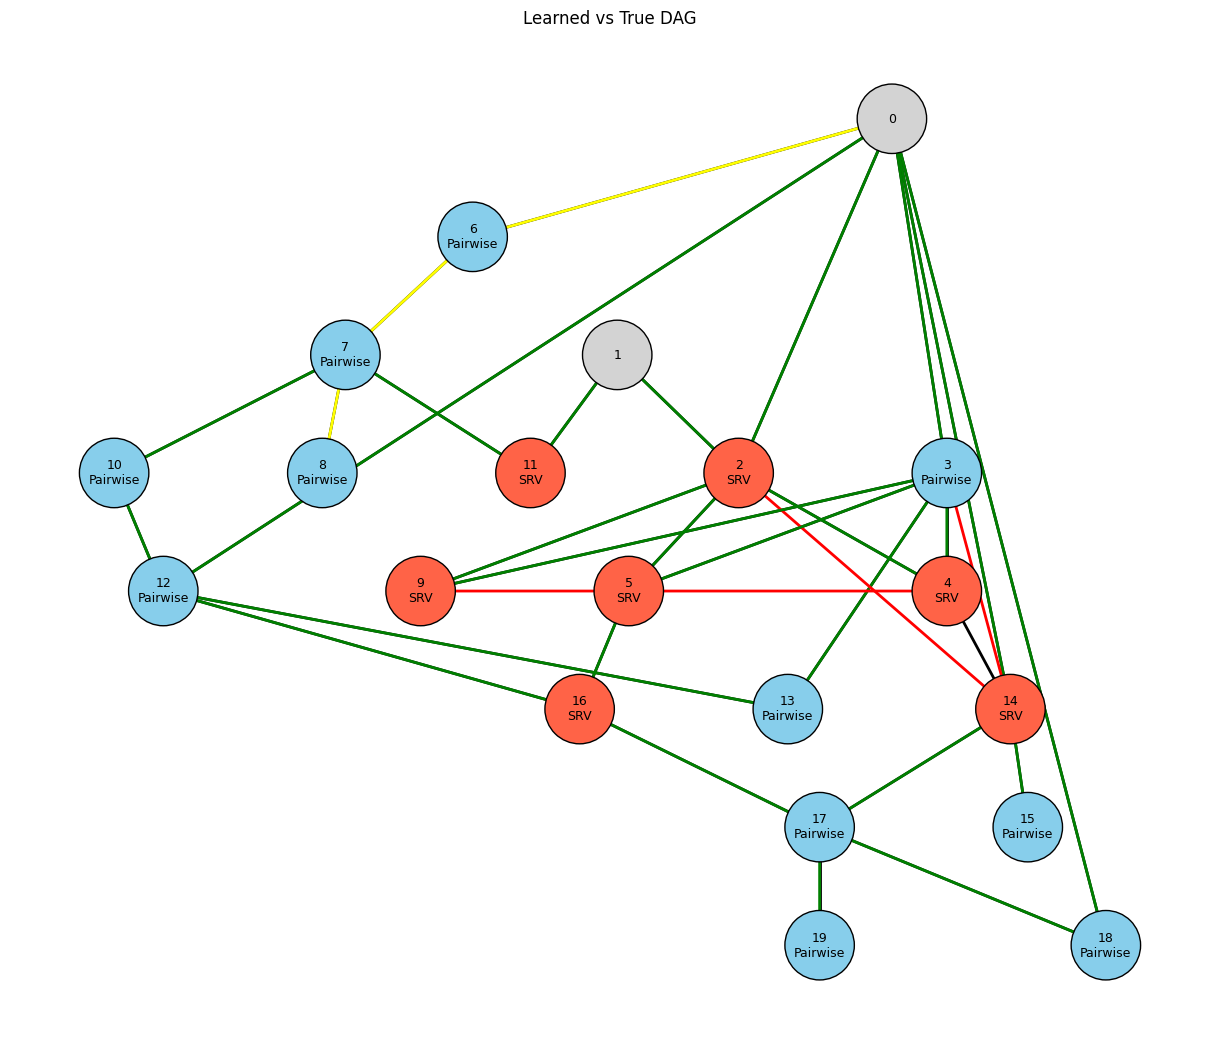

In [ ]:
g.compare_dags_with_labels()

## Hillclimber

In [ ]:
from algorithms.benchmark import run_hc
from pipeline.pipeline import Pipeline

configs = {
        # 'folder': 'data/precomputed_cpds/two_roots',
        "folder": 'data/BNs_Testing',
        'algorithm': 'genetic',
        'num_vars': 20,
        'num_samples': 10_000,
        'replications': 1
    }
pipeline = Pipeline(configs, run_hc)
pipeline.get_true_dags()

# pipeline.get_metrics()

In [ ]:
pipeline.get_results()

Processing CSV files:   0%|          | 0/3 [00:00<?, ?it/s]INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}
INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19'

{0: <networkx.classes.digraph.DiGraph at 0x77c2c97f3440>,
 1: <networkx.classes.digraph.DiGraph at 0x77c191123d10>,
 2: <networkx.classes.digraph.DiGraph at 0x77c1945602f0>}

In [ ]:
pipeline.get_metrics()

True triplets for 0: 0      [0, 2, 5]
3      [1, 7, 8]
4      [4, 7, 9]
10    [3, 4, 15]
11    [0, 8, 16]
12    [1, 8, 17]
Name: Combs, dtype: object
Learned triplets for 0: [('0', '16', '8'), ('0', '2', '5'), ('0', '14', '9'), ('1', '8', '7'), ('1', '8', '17'), ('7', '8', '17'), ('1', '17', '7'), ('3', '15', '4'), ('7', '4', '9'), ('9', '19', '16')]
✅ Correctly learned triplets:
[3, 4, 15]
[0, 2, 5]
[4, 7, 9]
[1, 7, 8]
[1, 8, 17]
[0, 8, 16]

❌ Missing triplets (true but not learned):

⚠️ Extra triplets (learned but not true):
[7, 8, 17]
[9, 16, 19]
[1, 7, 17]
[0, 9, 14]
True triplets for 1: 2       [0, 4, 7]
6     [3, 10, 11]
7      [2, 9, 12]
11    [1, 10, 16]
12    [3, 14, 17]
13    [1, 11, 18]
Name: Combs, dtype: object
Learned triplets for 1: [('0', '4', '7'), ('11', '1', '18'), ('1', '16', '10'), ('4', '3', '10'), ('4', '3', '11'), ('10', '3', '11'), ('3', '17', '14'), ('4', '11', '10'), ('5', '7', '14'), ('7', '19', '8'), ('9', '2', '12')]
✅ Correctly learned triplets:
[3, 14, 1

,0,1,2
True Positives,14.000000,14.000000,13.000000
False Positives,11.000000,15.000000,17.000000
False Negatives,9.000000,9.000000,11.000000
SHD,20.000000,24.000000,28.000000
Precision,0.560000,0.483000,0.433000
Recall,0.609000,0.609000,0.542000
F1 Score,0.583000,0.538000,0.481000
BIC,-68335.203545,-78173.603449,-81562.852655
triplets_found,6.000000,6.000000,6.000000


## Experiment 1

In [ ]:
from algorithms.ea import GeneticBNSearch

In [ ]:
df = pd.read_csv(f"{configs['folder']}/{pipeline.csv_by_id[5]}")

KeyError: 5

In [ ]:
df.columns = df.columns.astype(int)

In [ ]:
df.columns

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19'],
      dtype='object')

In [ ]:
from pgmpy.estimators import BIC

score = BIC(df)
# score.score(pipeline.true_dags[5])
# pipeline.true_dags[1].nodes()


INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}


KeyError: 0

In [ ]:
mapping = {i: str(i) for i in range(20)}
nx.relabel_nodes(pipeline.true_dags[1], mapping)
ea = GeneticBNSearch(data=df, score_fn="bic")
df.columns = df.columns.astype(str)
ea._score(graph=pipeline.true_dags[1])  # Use the true DAG for




INFO:pgmpy: Datatype (N=numerical, C=Categorical Unordered, O=Categorical Ordered) inferred from data: 
 {'0': 'N', '1': 'N', '2': 'N', '3': 'N', '4': 'N', '5': 'N', '6': 'N', '7': 'N', '8': 'N', '9': 'N', '10': 'N', '11': 'N', '12': 'N', '13': 'N', '14': 'N', '15': 'N', '16': 'N', '17': 'N', '18': 'N', '19': 'N'}


KeyError: 0

In [ ]:
pipeline.true_dags[0]

In [ ]:
with open(f"{configs['folder']}/{pipeline.metadata_by_id[0]}", "rb") as f:
    meta_df = dill.load(f)

In [ ]:
pipeline.true_dags[1]

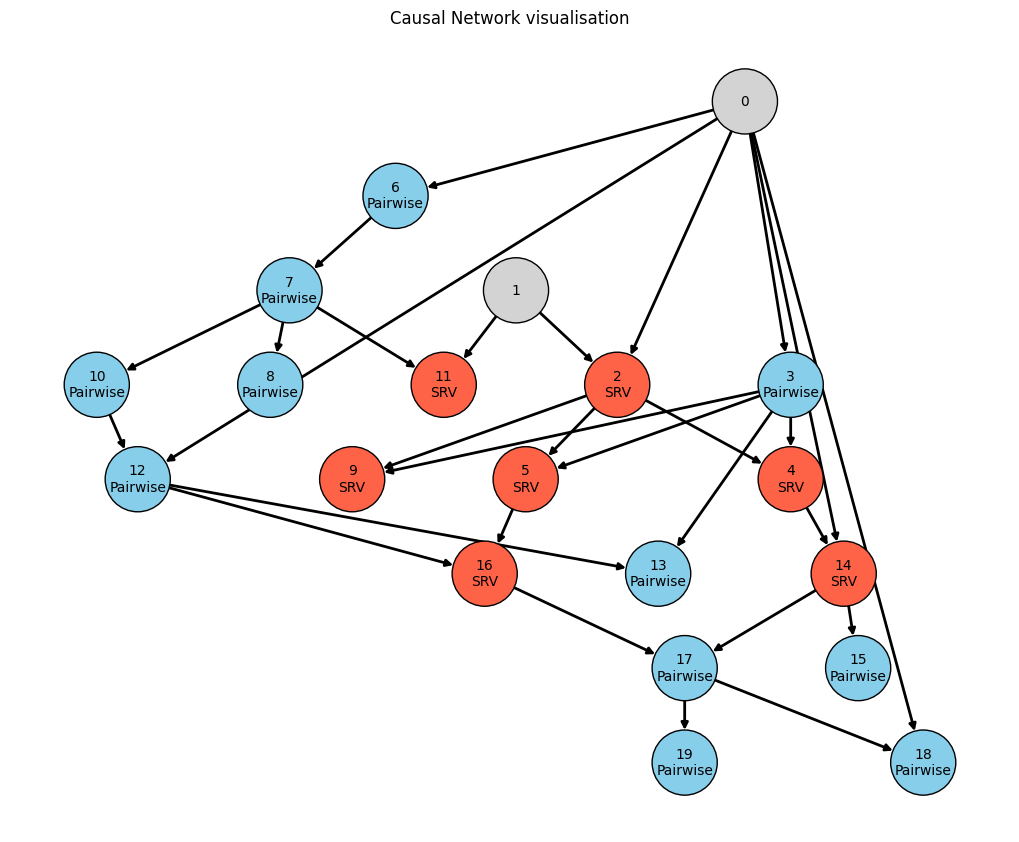

In [ ]:
viz = GraphVisualization(graph=pipeline.true_dags[0], metadata=meta_df)
viz.visualize_network_labels()

In [ ]:
pipeline.get_metrics()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,23.000,18.000,20.000,12.000,13.000,19.000,15.000,18.000,15.000,21.000,...,24.000,21.000,23.000,22.000,15.000,18.000,14.000,18.000,18.000,14.000
False Positives,11.000,19.000,21.000,24.000,25.000,20.000,18.000,10.000,15.000,6.000,...,13.000,16.000,8.000,19.000,16.000,18.000,19.000,24.000,18.000,16.000
False Negatives,6.000,10.000,9.000,17.000,13.000,10.000,12.000,9.000,11.000,6.000,...,5.000,6.000,4.000,8.000,13.000,11.000,14.000,10.000,10.000,13.000
SHD,17.000,29.000,30.000,41.000,38.000,30.000,30.000,19.000,26.000,12.000,...,18.000,22.000,12.000,27.000,29.000,29.000,33.000,34.000,28.000,29.000
Precision,0.676,0.486,0.488,0.333,0.342,0.487,0.455,0.643,0.500,0.778,...,0.649,0.568,0.742,0.537,0.484,0.500,0.424,0.429,0.500,0.467
Recall,0.793,0.643,0.690,0.414,0.500,0.655,0.556,0.667,0.577,0.778,...,0.828,0.778,0.852,0.733,0.536,0.621,0.500,0.643,0.643,0.519
F1 Score,0.730,0.554,0.571,0.369,0.406,0.559,0.500,0.655,0.536,0.778,...,0.727,0.656,0.793,0.620,0.508,0.554,0.459,0.514,0.563,0.491


In [ ]:
pipeline.eval_metrics

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
True Positives,23.000,18.000,20.000,12.000,13.000,19.000,15.000,18.000,15.000,21.000,...,24.000,21.000,23.000,22.000,15.000,18.000,14.000,18.000,18.000,14.000
False Positives,11.000,19.000,21.000,24.000,25.000,20.000,18.000,10.000,15.000,6.000,...,13.000,16.000,8.000,19.000,16.000,18.000,19.000,24.000,18.000,16.000
False Negatives,6.000,10.000,9.000,17.000,13.000,10.000,12.000,9.000,11.000,6.000,...,5.000,6.000,4.000,8.000,13.000,11.000,14.000,10.000,10.000,13.000
SHD,17.000,29.000,30.000,41.000,38.000,30.000,30.000,19.000,26.000,12.000,...,18.000,22.000,12.000,27.000,29.000,29.000,33.000,34.000,28.000,29.000
Precision,0.676,0.486,0.488,0.333,0.342,0.487,0.455,0.643,0.500,0.778,...,0.649,0.568,0.742,0.537,0.484,0.500,0.424,0.429,0.500,0.467
Recall,0.793,0.643,0.690,0.414,0.500,0.655,0.556,0.667,0.577,0.778,...,0.828,0.778,0.852,0.733,0.536,0.621,0.500,0.643,0.643,0.519
F1 Score,0.730,0.554,0.571,0.369,0.406,0.559,0.500,0.655,0.536,0.778,...,0.727,0.656,0.793,0.620,0.508,0.554,0.459,0.514,0.563,0.491
